# EOO functional enrichment: fine-mapped vs. marginal LR comparison


## Setup


In [1]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(data.table)
  library(tibble)
  library(ComplexHeatmap)
  library(circlize)
  library(grid)
  library(RColorBrewer)
})

figure_data_dir <- normalizePath("../figure_data", mustWork = FALSE)
dir.create(figure_data_dir, showWarnings = FALSE, recursive = TRUE)
figure_out_dir <- normalizePath(file.path(".", "figure_data"), mustWork = FALSE)
dir.create(figure_out_dir, showWarnings = FALSE, recursive = TRUE)

eoo_fm_vs_lr_path <- file.path(figure_data_dir, "Figure_1_EOO_FM_vs_LR_comparison.rds")

# ComplexHeatmap-friendly PDF saver (uses pdf()/draw()/dev.off()).
save_heatmap_pdf <- function(ht, filename_stub, width, height,
                              ht_gap = unit(5, "mm"),
                              heatmap_legend_side = "right",
                              annotation_legend_side = "right",
                              merge_legend = TRUE) {
  out_pdf <- file.path(figure_out_dir, paste0(filename_stub, ".pdf"))
  pdf(out_pdf, width = width, height = height)
  draw(ht, ht_gap = ht_gap,
       heatmap_legend_side = heatmap_legend_side,
       annotation_legend_side = annotation_legend_side,
       merge_legend = merge_legend)
  dev.off()
  message("Saved: ", out_pdf)
  invisible(out_pdf)
}


## Data Preparation

This section regenerates the cached RDS file used downstream:

- `eoo_fm_vs_lr_path` : aggregated EOO log2-enrichment matrices (rows = annotation
  Category, columns = study) for fine-mapped (univariate SuSiE) and marginal LR
  variant sets, restricted to annotations and studies shared by both pipelines.

The block is wrapped in `if (!file.exists(...))` so a re-run will skip
recomputation when the cached RDS exists on disk.

Inputs:
- `~/lab_data/ftp_fgc_xqtl/analysis_result/EOO/EOO_reshape_combined_result_withSNP_pip01_95cs_annotation_variant_level.updatedSep9th.RDS`
- `~/lab_data/ftp_fgc_xqtl/analysis_result/EOO/EOO_LR_enrichment_withmeta.rds`
- `~/lab_data/ftp_fgc_xqtl/analysis_result/EOO/categorized_annotation_tracks.csv`

Definitions:
- FM variants: `method == 'univariate'` (SuSiE, PIP > 0.01, 95% CS).
- LR variants: marginal linear regression top loci (study names normalized by
  stripping `_pure_lr` suffix and `ROSMAP_` prefix).
- Shared annotations / studies: intersection of FM and LR sets, excluding raw
  ENCFF and `Miscellaneous` categories.
- Cell value: mean of `Enrichment_log2` across shared annotations within a
  Category, restricted to `Enrichment_P_value < 0.05`.
- P-value matrix: per Category x study minimum `Enrichment_P_value`
  (unfiltered) across shared annotations.


In [3]:
# Inputs
eoo_fm_rds       <- "~/lab_data/ftp_fgc_xqtl/analysis_result/EOO/EOO_reshape_combined_result_withSNP_pip01_95cs_annotation_variant_level.updatedSep9th.RDS"
eoo_lr_rds       <- "~/lab_data/ftp_fgc_xqtl/analysis_result/EOO/EOO_LR_enrichment_withmeta.rds"
annotation_csv   <- "~/lab_data/ftp_fgc_xqtl/analysis_result/EOO/categorized_annotation_tracks.csv"

# Force regeneration by setting FORCE_REPREP <- TRUE before running
FORCE_REPREP <- if (exists("FORCE_REPREP")) FORCE_REPREP else FALSE


In [4]:
# Build Figure_1_EOO_FM_vs_LR_comparison.rds
if (FORCE_REPREP || !file.exists(eoo_fm_vs_lr_path)) {
  message("[eoo] reading FM input: ", eoo_fm_rds)
  eoo_res_all <- readRDS(eoo_fm_rds)

  # Clean annotation field and merge in track categorization
  enrichment_data <- eoo_res_all %>%
    mutate(Annotation = gsub('.to_hg38', '', Annotation)) %>%
    filter(!str_detect(Annotation, 'hg19'), !str_detect(Annotation, 'ENCFF')) %>%
    mutate(Annotation = ifelse(
      str_detect(Annotation, 'ENCFF038KTR|ENCFF015DGX|ENCFF370ANN'),
      str_replace(Annotation, '\\.bed$', '.bed.gz'),
      Annotation
    )) %>%
    distinct()

  track_df <- fread(annotation_csv)
  enrichment_data <- merge(enrichment_data, track_df,
                           by.x = 'Annotation', by.y = 'Track', all.x = TRUE) %>%
    select(-Source) %>% distinct() %>%
    mutate(Annotation = paste0(Category, "|", Annotation)) %>%
    filter(!str_detect(Annotation, "ENCFF"))

  # FM: univariate SuSiE
  fm_univ <- enrichment_data %>%
    filter(method == 'univariate') %>%
    mutate(study_norm = gsub('_brain$', '', study))

  # LR
  message("[eoo] reading LR input: ", eoo_lr_rds)
  lr_raw <- readRDS(eoo_lr_rds)
  lr_norm <- lr_raw %>%
    mutate(
      study_norm = gsub('^ROSMAP_', '', gsub('_pure_lr$', '', study)),
      Annotation = as.character(Annotation)
    ) %>%
    filter(!is.na(Category), !str_detect(Annotation, 'ENCFF'),
           Category != 'Miscellaneous')

  # Shared annotations / studies
  shared_anns    <- intersect(unique(lr_norm$Annotation), unique(fm_univ$Annotation))
  shared_studies <- intersect(unique(lr_norm$study_norm), unique(fm_univ$study_norm))
  message("[eoo] shared annotations: ", length(shared_anns),
          " | shared studies: ", length(shared_studies))

  # Helpers: assign Super_category and QTL_type
  add_supercat <- function(df) {
    df %>% mutate(Super_category = case_when(
      Category %in% c("CellType_Neuron", "CellType_Astrocyte", "CellType_Microglia_Myeloid",
                      "CellType_Oligodendrocyte", "CellType_Progenitor",
                      "CellType_Neuroblastoma", "CellType_OtherNonNeural", "CellType_Vascular") ~ "CellType_specific",
      Category %in% c("eQTL", "sQTL") ~ "Molecular_QTL",
      Category %in% c("Epigenetic_Histone_Modifications", "Chromatin_Accessibility",
                      "Chromatin_Interaction_Loops", "Enhancer_SuperEnhancer",
                      "Promoter", "Transcription_Factor_Binding", "Transcription_Factor_Footprints") ~ "Epigenetic_Regulation",
      Category == "Genomic_Conservation" ~ "Conservation",
      TRUE ~ "Other"
    ))
  }
  add_qtltype <- function(df) {
    df %>% mutate(QTL_type = case_when(
      str_detect(study_norm, 'Oli|OPC|Mic|Ast|Exc|Inh|monocyte') ~ "snuc-eQTL",
      str_detect(study_norm, 'pQTL')                              ~ "pQTL",
      str_detect(study_norm, 'eQTL|AC|PCC|DLPFC|Knight')         ~ "eQTL",
      TRUE ~ "Other"
    ))
  }

  # Aggregated mean log2 enrichment per Category x study (p < 0.05, shared anns)
  agg_fm <- fm_univ %>%
    filter(study_norm %in% shared_studies, Annotation %in% shared_anns,
           Enrichment_P_value < 0.05) %>%
    add_supercat() %>% add_qtltype() %>%
    group_by(Category, Super_category, study_norm, QTL_type) %>%
    summarise(mean_log2 = mean(Enrichment_log2[is.finite(Enrichment_log2)],
                                na.rm = TRUE), .groups = 'drop')

  agg_lr <- lr_norm %>%
    filter(study_norm %in% shared_studies, Annotation %in% shared_anns,
           Enrichment_P_value < 0.05) %>%
    add_supercat() %>% add_qtltype() %>%
    group_by(Category, Super_category, study_norm, QTL_type) %>%
    summarise(mean_log2 = mean(Enrichment_log2[is.finite(Enrichment_log2)],
                                na.rm = TRUE), .groups = 'drop')

  # Row ordering: Category sorted by Super_category
  sc_order <- c("Molecular_QTL", "CellType_specific",
                "Epigenetic_Regulation", "Conservation", "Other")
  shared_cats <- intersect(unique(agg_fm$Category), unique(agg_lr$Category))
  cat_order_df <- bind_rows(agg_fm, agg_lr) %>%
    distinct(Category, Super_category) %>%
    filter(Category %in% shared_cats) %>%
    mutate(Super_category = factor(Super_category, levels = sc_order)) %>%
    arrange(Super_category, Category)
  cat_levels <- cat_order_df$Category

  # Column ordering: study sorted by QTL_type then alphabetically
  study_info <- bind_rows(agg_fm, agg_lr) %>%
    distinct(study_norm, QTL_type) %>%
    mutate(QTL_type = factor(QTL_type, levels = c("eQTL", "snuc-eQTL", "pQTL", "Other"))) %>%
    arrange(QTL_type, study_norm)
  study_levels <- study_info$study_norm

  # Wide matrices: rows = Category, columns = study
  make_mat <- function(agg_df, cat_lvls, study_lvls) {
    m <- agg_df %>%
      select(Category, study_norm, mean_log2) %>%
      pivot_wider(names_from = study_norm, values_from = mean_log2) %>%
      column_to_rownames('Category') %>%
      as.matrix()
    r <- cat_lvls[cat_lvls %in% rownames(m)]
    c <- study_lvls[study_lvls %in% colnames(m)]
    m[r, c, drop = FALSE]
  }
  mat_fm <- make_mat(agg_fm, cat_levels, study_levels)
  mat_lr <- make_mat(agg_lr, cat_levels, study_levels)

  # Min p-value per Category x study across shared annotations (unfiltered)
  make_pval_mat <- function(df, cat_lvls, study_lvls) {
    pv <- df %>%
      group_by(Category, study_norm) %>%
      summarise(min_pval = min(Enrichment_P_value, na.rm = TRUE), .groups = 'drop') %>%
      pivot_wider(names_from = study_norm, values_from = min_pval) %>%
      column_to_rownames('Category') %>%
      as.matrix()
    r <- cat_lvls[cat_lvls %in% rownames(pv)]
    c <- study_lvls[study_lvls %in% colnames(pv)]
    pv[r, c, drop = FALSE]
  }
  pval_fm <- make_pval_mat(
    fm_univ %>% filter(study_norm %in% shared_studies, Annotation %in% shared_anns) %>%
      add_supercat() %>% add_qtltype(),
    cat_levels, study_levels
  )
  pval_lr <- make_pval_mat(
    lr_norm %>% filter(study_norm %in% shared_studies, Annotation %in% shared_anns) %>%
      add_supercat() %>% add_qtltype(),
    cat_levels, study_levels
  )

  message("[eoo] mat_fm: ", paste(dim(mat_fm), collapse = " x "),
          " | mat_lr: ", paste(dim(mat_lr), collapse = " x "))

  out <- list(
    data = list(
      mat_fm       = mat_fm,
      mat_lr       = mat_lr,
      pval_fm      = pval_fm,
      pval_lr      = pval_lr,
      cat_order_df = as.data.frame(cat_order_df),
      study_info   = as.data.frame(study_info),
      sc_order     = sc_order
    ),
    meta = list(
      input_fm_rds  = eoo_fm_rds,
      input_lr_rds  = eoo_lr_rds,
      annotation_csv = annotation_csv,
      fm_def        = "univariate SuSiE; PIP > 0.01; 95% CS",
      lr_def        = "marginal LR top loci (study names normalized: strip _pure_lr suffix and ROSMAP_ prefix)",
      cell_value    = "mean(Enrichment_log2) per Category x study; shared annotations; Enrichment_P_value < 0.05",
      pval_def      = "min(Enrichment_P_value) per Category x study; shared annotations; unfiltered",
      generated_at  = format(Sys.time(), "%Y-%m-%d %H:%M:%S")
    )
  )
  saveRDS(out, eoo_fm_vs_lr_path)
  message("[eoo] saved: ", eoo_fm_vs_lr_path)
  invisible(out)
} else {
  message("[eoo] cache hit: ", eoo_fm_vs_lr_path)
}


[eoo] reading FM input: ~/lab_data/ftp_fgc_xqtl/analysis_result/EOO/EOO_reshape_combined_result_withSNP_pip01_95cs_annotation_variant_level.updatedSep9th.RDS

[eoo] reading LR input: ~/lab_data/ftp_fgc_xqtl/analysis_result/EOO/EOO_LR_enrichment_withmeta.rds

[eoo] shared annotations: 432 | shared studies: 17

Warning message:
“There were 17 warnings in `summarise()`.
The first warning was:
ℹ In argument: `min_pval = min(Enrichment_P_value, na.rm = TRUE)`.
ℹ In group 205: `Category = "Genomic_Conservation"`, `study_norm =
  "AC_DeJager_eQTL"`.
Caused by warning in `min()`:
! no non-missing arguments to min; returning Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 16 remaining warnings.”
[eoo] mat_fm: 17 x 17 | mat_lr: 17 x 17

[eoo] saved: /mnt/lustre/lab/gwang/users/rf2872/Work/codes/xqtl-paper/main_text/2_single_context_cis/figure_data/Figure_1_EOO_FM_vs_LR_comparison.rds



## Main Figure Data and Helpers


In [5]:
Figure_1_eoo <- readRDS(eoo_fm_vs_lr_path)

mat_fm       <- Figure_1_eoo$data$mat_fm
mat_lr       <- Figure_1_eoo$data$mat_lr
cat_order_df <- Figure_1_eoo$data$cat_order_df
study_info   <- Figure_1_eoo$data$study_info
sc_order     <- Figure_1_eoo$data$sc_order

# Shared log2-enrichment color scale (FM can reach ~6, LR ~2)
col_fun_eoo <- colorRamp2(
  c(-2, 0, 1, 2, 3, 4, 6),
  c("#2166AC", "#FFFFFF", "#FDDBC7", "#F4A582", "#D6604D", "#B2182B", "#67001F")
)

# QTL type palette (matches sLDSC panel style)
qtl_levels <- c("eQTL", "snuc-eQTL", "pQTL")
qtl_pal    <- c("eQTL" = "#4C72B0", "snuc-eQTL" = "#C44E52", "pQTL" = "#8172B2")

# Column split by QTL_type; row split by Super_category
col_split_vec <- factor(
  setNames(study_info$QTL_type, study_info$study_norm)[colnames(mat_fm)],
  levels = qtl_levels
)
row_split_vec <- factor(
  setNames(as.character(cat_order_df$Super_category),
           cat_order_df$Category)[rownames(mat_fm)],
  levels = sc_order
)

clean_eoo_context_label <- function(x) {
  x <- gsub("_(eQTL|sQTL|pQTL)$", "", x, perl = TRUE)
  x <- gsub("_", " ", x, fixed = TRUE)
  x <- gsub("DeJager", "CUIMC1", x, fixed = TRUE)
  trimws(x)
}

# Top annotation: colored block per QTL_type
make_top_anno <- function() {
  HeatmapAnnotation(
    QTL = anno_block(
      gp = gpar(fill = qtl_pal[qtl_levels], col = NA),
      height = unit(3, "mm"),
      labels = qtl_levels,
      labels_gp = gpar(fontsize = 9, col = "white", fontface = "bold")
    ),
    show_annotation_name = FALSE
  )
}


## Main Figure: EOO FM vs LR Comparison


In [6]:
nr <- nrow(mat_fm); nc <- ncol(mat_fm)

# FM heatmap (left panel): Super_category group titles on LEFT, row names hidden
ht_fm <- Heatmap(
  mat_fm, name = "log2_Enrichment",
  col = col_fun_eoo, na_col = "grey90",
  width  = unit(nc * 5.0, "mm"),
  height = unit(nr * 4.0, "mm"),
  cluster_rows = FALSE, cluster_columns = FALSE,
  show_row_dend = FALSE, show_column_dend = FALSE,
  row_split = row_split_vec, column_split = col_split_vec,
  cluster_row_slices = FALSE, cluster_column_slices = FALSE,
  top_annotation = make_top_anno(),
  column_title = "Fine-mapped (univariate)",
  column_title_gp = gpar(fontsize = 11, fontface = "bold"),
  row_title_gp  = gpar(fontsize = 8, fontface = "bold"),
  row_title_rot = 90,
  show_row_names = FALSE,
  show_column_names = TRUE,
  column_labels = clean_eoo_context_label(colnames(mat_fm)),
  column_names_gp = gpar(fontsize = 7.5),
  column_names_rot = 60, column_names_max_height = unit(5.0, "cm"),
  row_gap = unit(2, "mm"), column_gap = unit(2.5, "mm"),
  rect_gp = gpar(col = "white", lwd = 0.6), border = FALSE,
  show_heatmap_legend = TRUE,
  heatmap_legend_param = list(
    title = "log2 Enrichment",
    title_gp = gpar(fontsize = 11, fontface = "bold"),
    labels_gp = gpar(fontsize = 10),
    at = c(-2, 0, 2, 4, 6),
    labels = c("-2", "0", "2", "4", "6"),
    legend_height = unit(4.5, "cm"), grid_width = unit(5, "mm")
  )
)

# LR heatmap (right panel): group titles hidden, Category names on RIGHT
ht_lr <- Heatmap(
  mat_lr, name = "LR_log2",
  col = col_fun_eoo, na_col = "grey90",
  width  = unit(nc * 5.0, "mm"),
  height = unit(nr * 4.0, "mm"),
  cluster_rows = FALSE, cluster_columns = FALSE,
  show_row_dend = FALSE, show_column_dend = FALSE,
  row_split = row_split_vec, column_split = col_split_vec,
  cluster_row_slices = FALSE, cluster_column_slices = FALSE,
  top_annotation = make_top_anno(),
  column_title = "Marginal LR",
  column_title_gp = gpar(fontsize = 11, fontface = "bold"),
  row_title_gp  = gpar(fontsize = 0),
  show_row_names = TRUE,
  row_labels = gsub("_", " ", rownames(mat_lr)),
  row_names_side = "right",
  row_names_gp   = gpar(fontsize = 8.5),
  show_column_names = TRUE,
  column_labels = clean_eoo_context_label(colnames(mat_fm)),
  column_names_gp = gpar(fontsize = 7.5),
  column_names_rot = 60, column_names_max_height = unit(5.0, "cm"),
  row_gap = unit(2, "mm"), column_gap = unit(2.5, "mm"),
  rect_gp = gpar(col = "white", lwd = 0.6), border = FALSE,
  show_heatmap_legend = FALSE
)

ht_pair <- ht_fm + ht_lr


## Save Publication Files


In [7]:
save_heatmap_pdf(ht_pair, "EOO_FM_vs_LR_comparison",
                 width = 15.5, height = 7.2)


Saved: /mnt/lustre/lab/gwang/users/rf2872/Work/codes/xqtl-paper/main_text/2_single_context_cis/figure_data/EOO_FM_vs_LR_comparison.pdf



## Preview


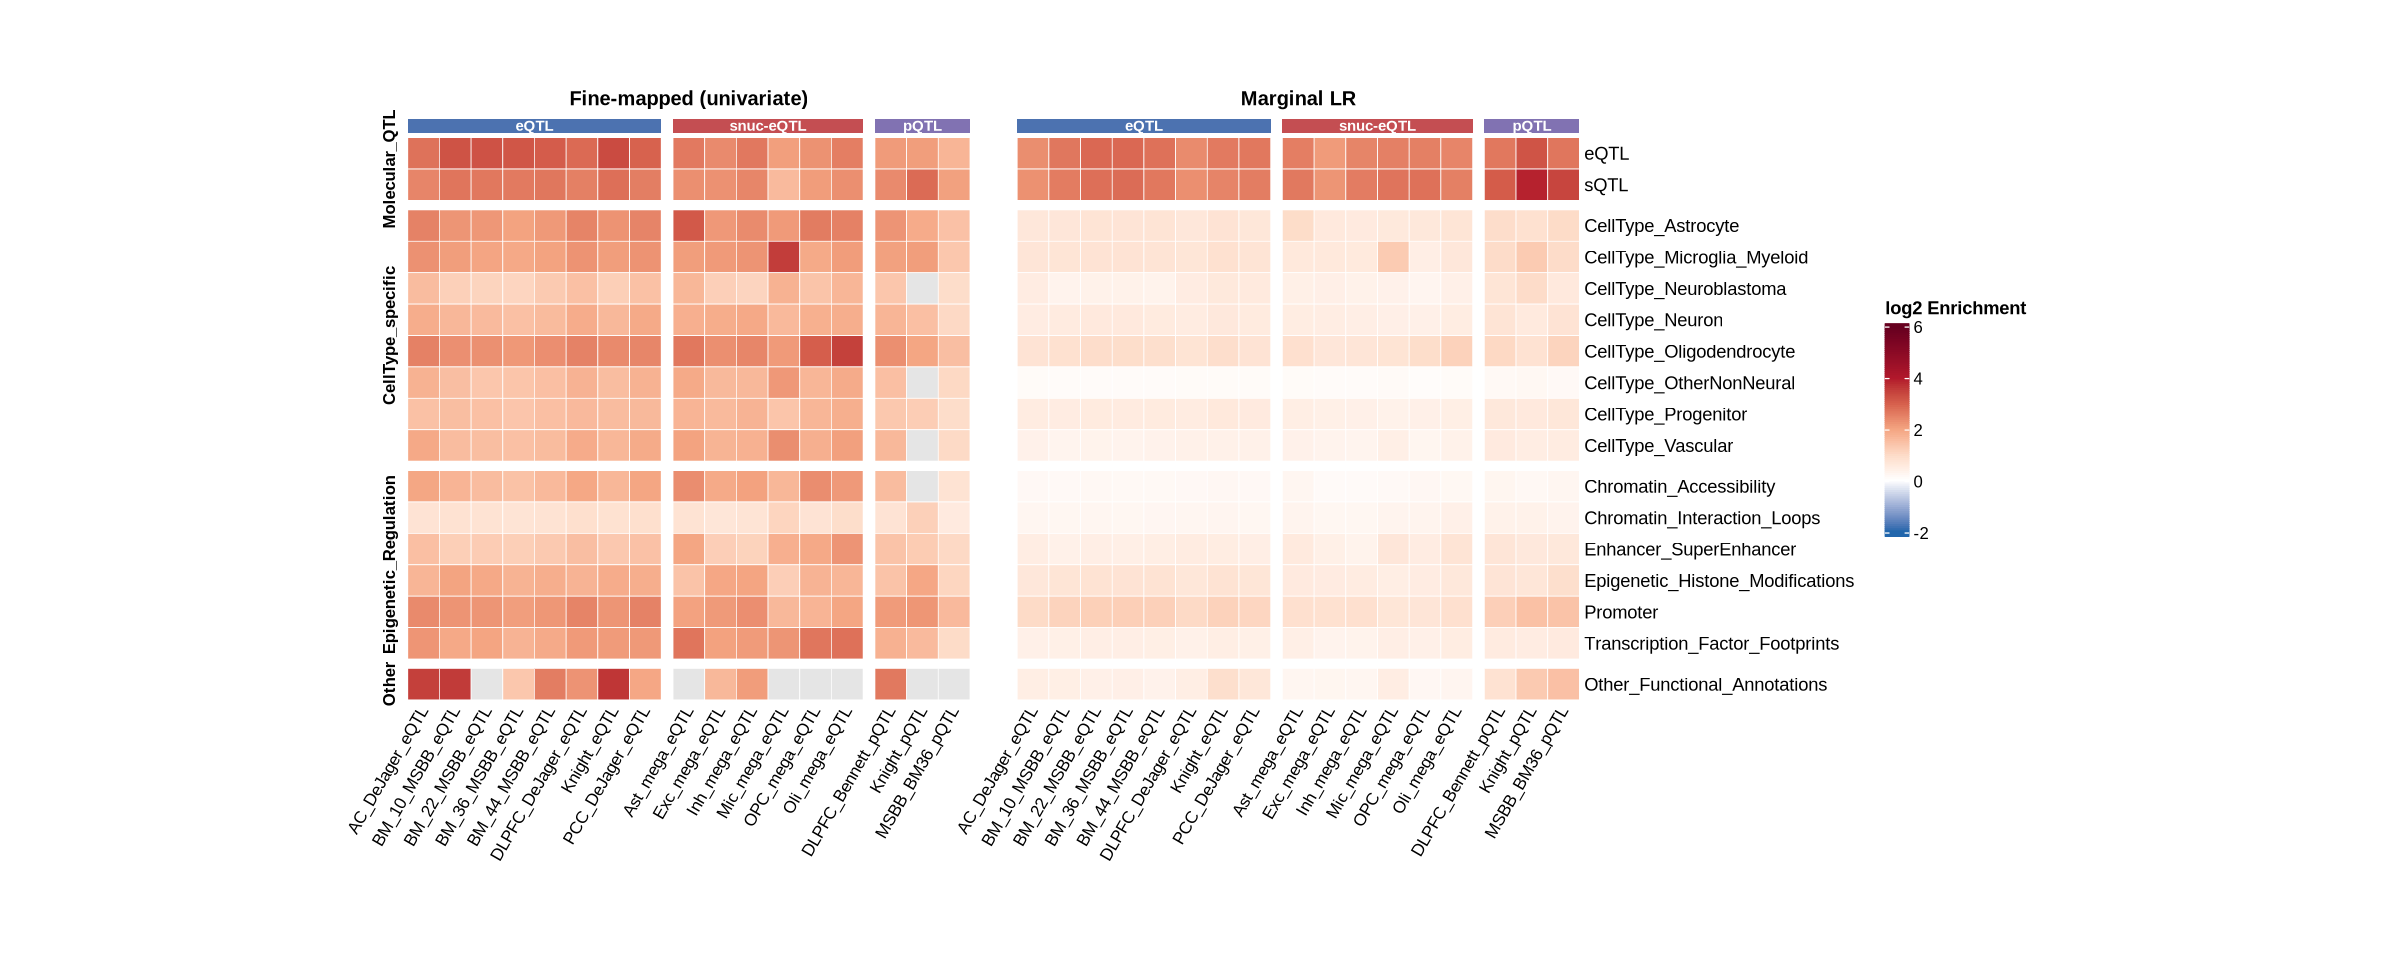

In [8]:
options(repr.plot.width = 20, repr.plot.height = 8)
draw(ht_pair, ht_gap = unit(5, "mm"),
     heatmap_legend_side = "right", annotation_legend_side = "right",
     merge_legend = TRUE)
